In [1]:
# pip install torch torchvision scikit-learn matplotlib seaborn tqdm

import os, random, copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset, Subset
import torchvision
import torchvision.transforms as T
from torchvision.models import resnet18

from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    roc_curve, classification_report
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
DATA_ROOT = Path('./data')
SAMPLES_PER_PARTITION = 5000

base_transform = T.Compose([
    T.ToTensor(),
])

mnist_train = torchvision.datasets.MNIST(DATA_ROOT, train=True,  download=True, transform=base_transform)
mnist_test  = torchvision.datasets.MNIST(DATA_ROOT, train=False, download=True, transform=base_transform)
print(f'Train: {len(mnist_train)}, Test: {len(mnist_test)}')

Train: 60000, Test: 10000


In [3]:
def attack_gaussian_noise(img: torch.Tensor, std: float = 0.15) -> torch.Tensor:
    return (img + torch.randn_like(img) * std).clamp(0, 1)


def attack_salt_pepper(img: torch.Tensor, prob: float = 0.10) -> torch.Tensor:
    out = img.clone()
    mask = torch.rand_like(img)
    out[mask < prob / 2]  = 0.0
    out[mask > 1 - prob / 2] = 1.0
    return out


def attack_geometric(img: torch.Tensor, magnitude: float = 6.0) -> torch.Tensor:
    transform = T.ElasticTransform(alpha=magnitude * 50, sigma=magnitude)
    return transform(img)


def attack_blending(img: torch.Tensor, alpha: float = 0.25) -> torch.Tensor:
    pattern = torch.rand_like(img)
    return ((1 - alpha) * img + alpha * pattern).clamp(0, 1)


def attack_trigger(img: torch.Tensor, trigger_size: int = 5) -> torch.Tensor:
    out = img.clone()
    H, W = img.shape[-2], img.shape[-1]
    x = random.randint(0, W - trigger_size)
    y = random.randint(0, H - trigger_size)
    out[:, y:y+trigger_size, x:x+trigger_size] = 1.0
    return out


ATTACKS = {
    'attack_a': attack_gaussian_noise,
    'attack_b': attack_salt_pepper,
    'attack_c': attack_geometric,
    'attack_d': attack_blending,
    'attack_e': attack_trigger,
}

In [4]:
class TransformSubset(Dataset):
    def __init__(self, subset, attack_fn=None, is_poisoned=0):
        self.subset = subset
        self.attack_fn = attack_fn
        self.is_poisoned = is_poisoned

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.attack_fn:
            img = self.attack_fn(img)
        return img, label, self.is_poisoned

def create_joined_poisoned_dataset(base_dataset, attack_fn):
    
    clean_subset = TransformSubset(base_dataset, attack_fn=None, is_poisoned=0)
    poison_subset = TransformSubset(base_dataset, attack_fn=attack_fn, is_poisoned=1)
    
    # Join the clean and poisoned data
    return ConcatDataset([clean_subset, poison_subset])


In [5]:
import pytorch_lightning as pl

class LitAutoEncoder(pl.LightningModule):
    def __init__(self, input_dim=28*28, hidden_dim=128, latent_dim=32):
        super().__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim)
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # Images are 0-1 scaled
        )
        
        self.criterion = nn.MSELoss()

    def forward(self, x):
        batch_size = x.size(0)
        x_flat = x.view(batch_size, -1)
        
        z = self.encoder(x_flat)
        x_reconstructed = self.decoder(z)
        
        return x_reconstructed.view(x.shape)

    def training_step(self, batch, batch_idx):
        # batch contains: img, label, is_poisoned
        x = batch[0]
        x_hat = self(x)
        
        loss = self.criterion(x_hat, x)
        self.log('train_loss', loss, prog_bar=True)
        return loss
        
    def validation_step(self, batch, batch_idx):
        x = batch[0]
        x_hat = self(x)
        
        loss = self.criterion(x_hat, x)
        self.log('val_loss', loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

In [6]:
# Create dataset for this attack
from pytorch_lightning import Trainer


clean_subset = TransformSubset(mnist_train, attack_fn=None, is_poisoned=0)

# Split train dataset into train and validation (80/20 split)
train_size = int(0.8 * len(clean_subset))
val_size = len(clean_subset) - train_size
train_split, val_split = torch.utils.data.random_split(clean_subset, [train_size, val_size])

# Initialize DataLoaders
train_loader = DataLoader(train_split, batch_size=64, shuffle=True)
val_loader = DataLoader(val_split, batch_size=64, shuffle=False)

# Initialize Model and Trainer
model = LitAutoEncoder()
trainer = Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    log_every_n_steps=10,
    enable_model_summary=False,
)

# Start training
trainer.fit(model, train_loader, val_loader)



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA GeForce RTX 3080') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec,
LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

c:\Users\agata\anaconda3\envs\ml\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=10` reached.


Clean Mean MSE: 0.0076 +/- 0.0045
Attack B Mean MSE: 0.0599 +/- 0.0098


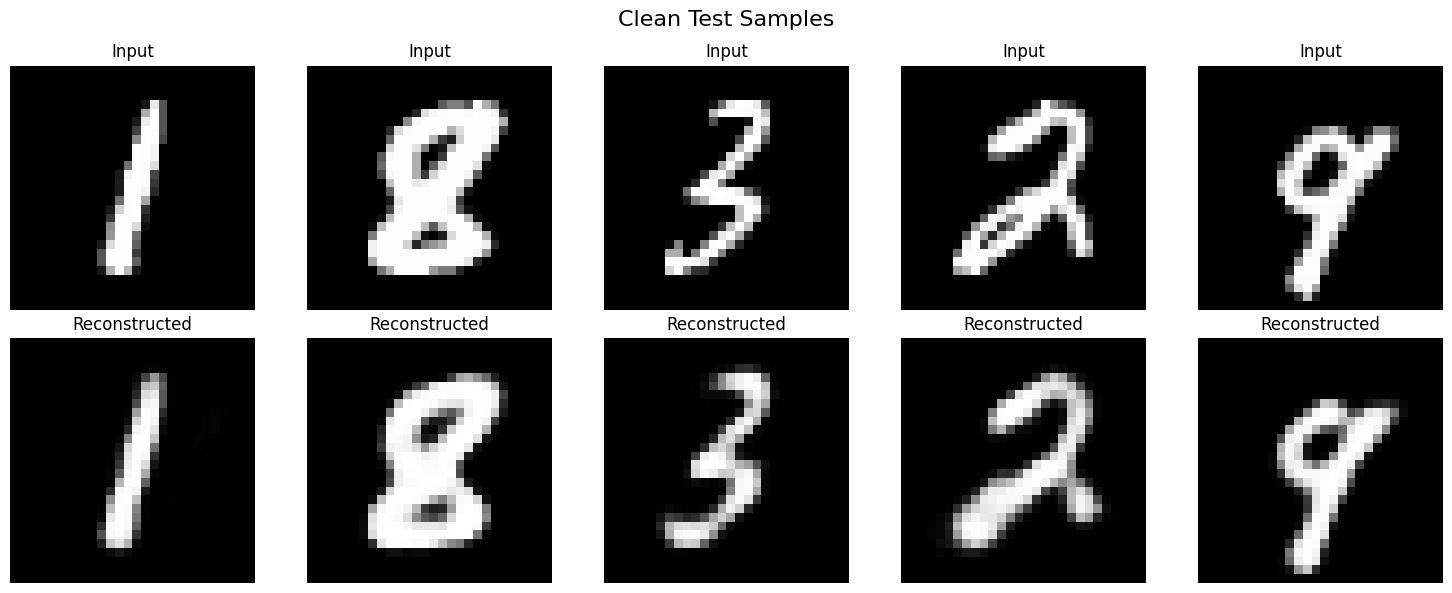

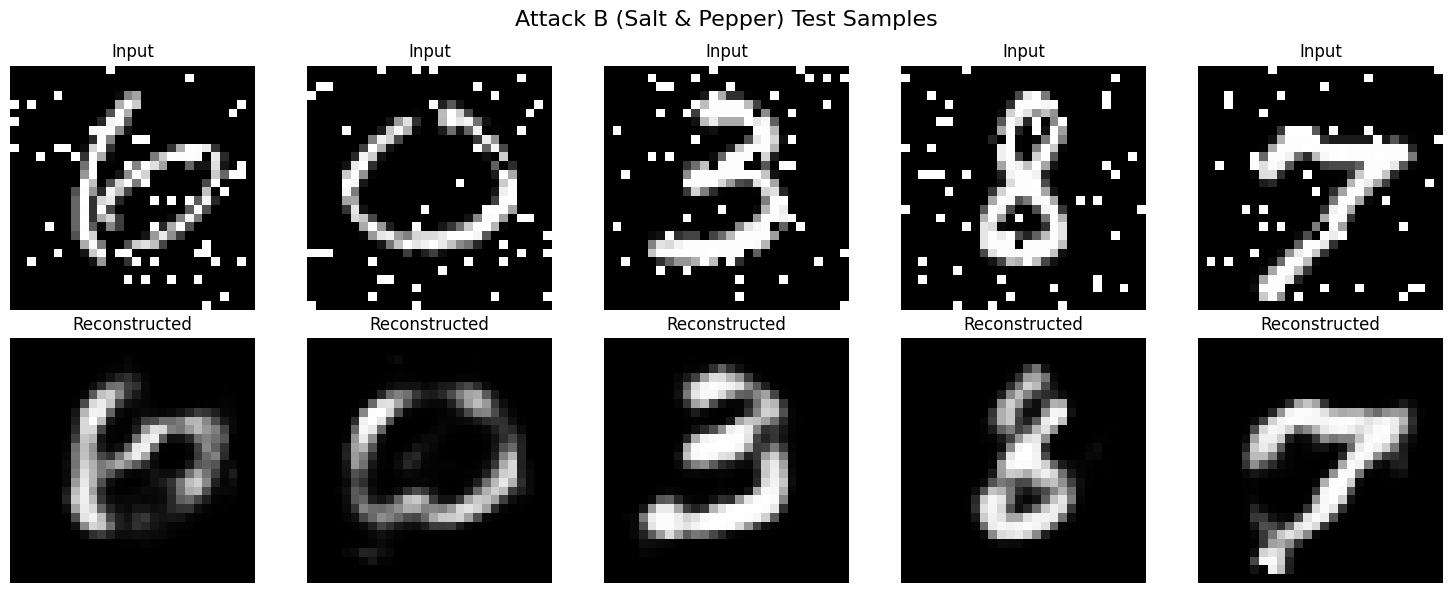

In [ ]:
# Create Test DataLoaders for Clean and Attack B
clean_test = TransformSubset(mnist_test, attack_fn=None, is_poisoned=0)
attack_b_test = TransformSubset(mnist_test, attack_fn=ATTACKS['attack_b'], is_poisoned=1)

clean_test_loader = DataLoader(clean_test, batch_size=256, shuffle=False)
attack_b_test_loader = DataLoader(attack_b_test, batch_size=256, shuffle=False)

def evaluate_reconstruction(model, loader):
    model.eval()
    model.to(DEVICE)
    losses = []
    criterion = nn.MSELoss(reduction='none')
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(DEVICE)
            x_hat = model(x)
            
            # Compute MSE per image
            loss = criterion(x_hat, x)
            loss_per_image = loss.view(loss.size(0), -1).mean(dim=1)
            losses.extend(loss_per_image.cpu().numpy())
    return np.array(losses)

clean_losses = evaluate_reconstruction(model, clean_test_loader)
attack_losses = evaluate_reconstruction(model, attack_b_test_loader)

print(f"Clean Mean MSE: {clean_losses.mean():.4f} +/- {clean_losses.std():.4f}")
print(f"Attack B Mean MSE: {attack_losses.mean():.4f} +/- {attack_losses.std():.4f}")

# Calculate ROC AUC
y_true = np.concatenate([np.zeros(len(clean_losses)), np.ones(len(attack_losses))])
y_scores = np.concatenate([clean_losses, attack_losses])

auc = roc_auc_score(y_true, y_scores)
print(f"ROC AUC for detecting attack_b: {auc:.4f}")

# Visualize some examples
def show_reconstructions(model, dataset, title=""):
    model.eval()
    model.to(DEVICE)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle(title, fontsize=16)
    
    indices = np.random.choice(len(dataset), 5, replace=False)
    
    for i, idx in enumerate(indices):
        x = dataset[idx][0].unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            x_hat = model(x)
        
        # Original (or Attacked)
        axes[0, i].imshow(x.squeeze().cpu().numpy(), cmap='gray')
        axes[0, i].set_title("Input")
        axes[0, i].axis('off')
        
        # Reconstructed
        axes[1, i].imshow(x_hat.squeeze().cpu().numpy(), cmap='gray')
        axes[1, i].set_title("Reconstructed")
        axes[1, i].axis('off')
        
    plt.tight_layout()
    plt.show()

show_reconstructions(model, clean_test, title="Clean Test Samples")
show_reconstructions(model, attack_b_test, title="Attack B (Salt & Pepper) Test Samples")